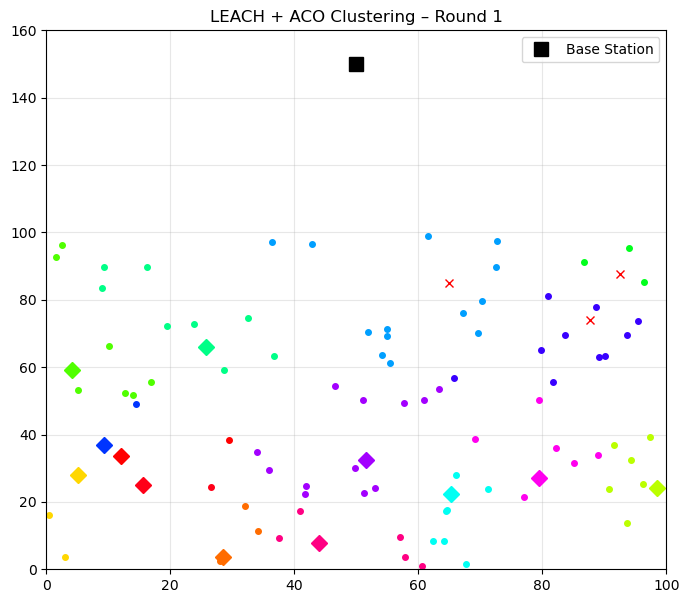

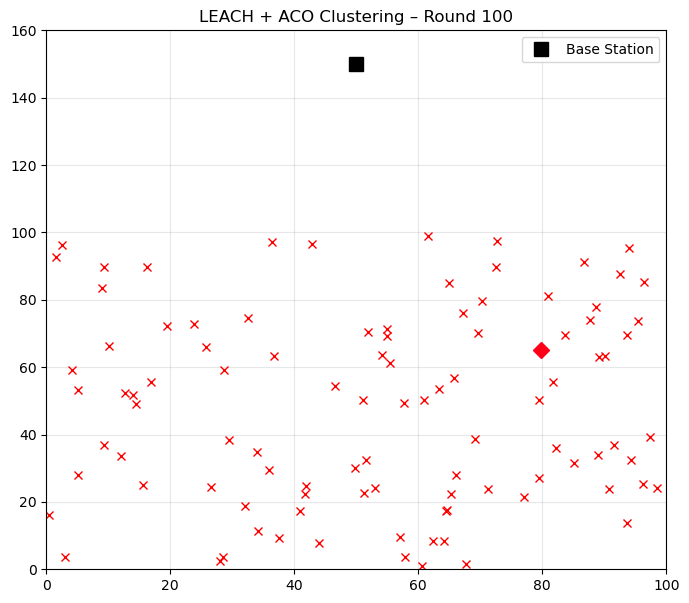

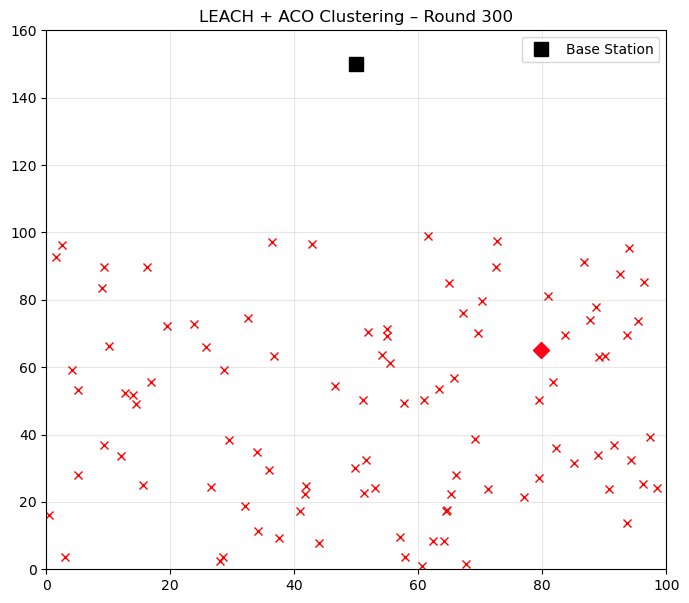

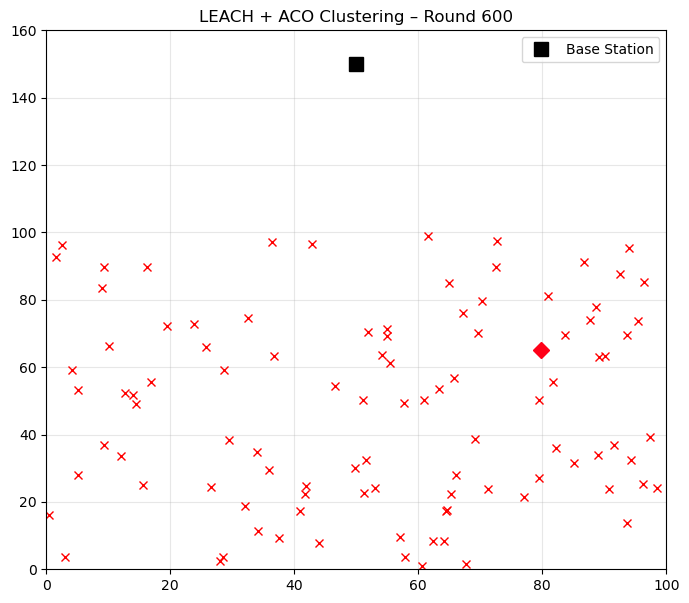

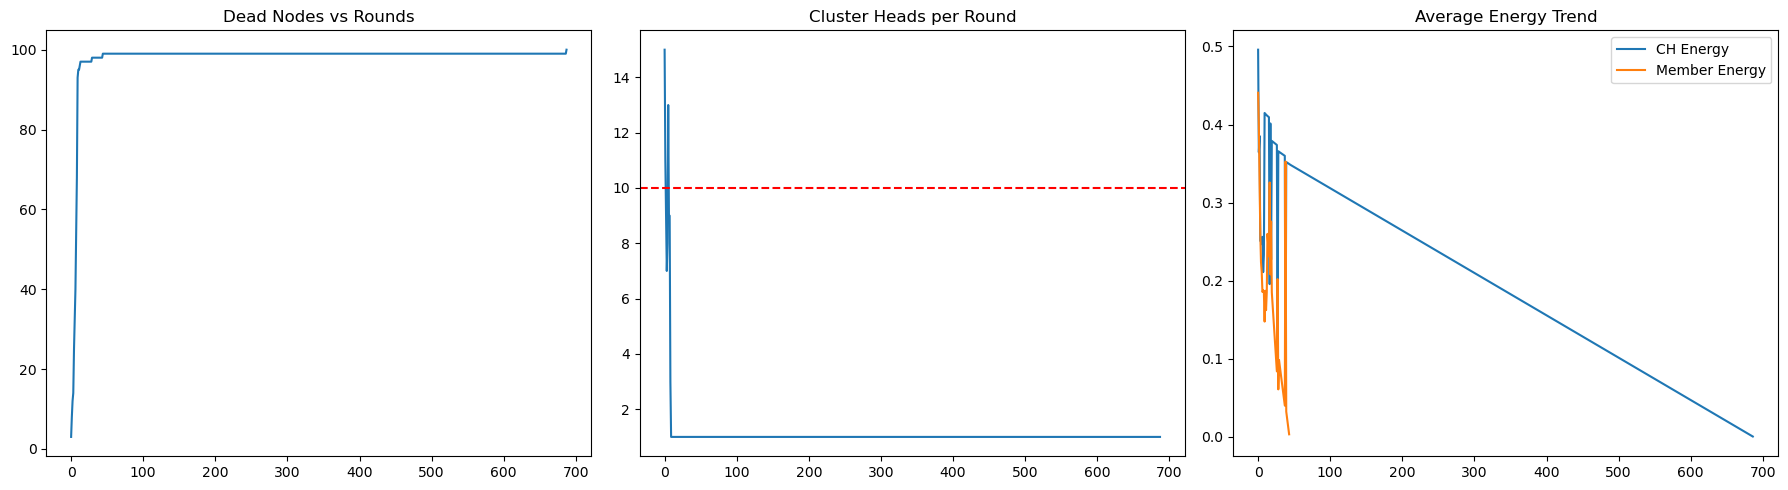

Simulation Finished
First Node Death: 0
Total Rounds Simulated: 688


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import random

# ------------------ CONSTANTS ------------------
NUM_NODES = 100
FIELD_SIZE = 100
NUM_ROUNDS = 2000

E_elec = 50e-9
E_fs   = 50e-9
E_mp   = 0.0013e-12
d0 = 87
P = 0.1
E_DATA_BITS = 4000

BS_X, BS_Y = FIELD_SIZE / 2, FIELD_SIZE + 50

np.random.seed(42)
random.seed(42)

EPOCH = int(1 / P)

# ------------------ ACO PARAMETERS ------------------
ALPHA = 1.0
BETA  = 2.0
RHO   = 0.5
Q     = 100

# ------------------ NODE CLASS ------------------
class Node:
    def __init__(self, i, x, y, energy):
        self.id = i
        self.x = x
        self.y = y
        self.energy = energy
        self.is_dead = False
        self.is_cluster_head = False
        self.cluster_head_id = None
        self.rounds_since_ch = EPOCH

    def distance(self, x, y):
        return np.sqrt((self.x - x)**2 + (self.y - y)**2)

    def tx_energy(self, d, bits=E_DATA_BITS):
        if d <= d0:
            return E_elec * bits + E_fs * bits * d**2
        else:
            return E_elec * bits + E_mp * bits * d**4

    def consume(self, e):
        self.energy -= e
        if self.energy <= 0:
            self.energy = 0
            self.is_dead = True

# ------------------ INITIALIZATION ------------------
def initialize_network():
    nodes = []
    energies = np.clip(np.random.normal(0.5, 0.1, NUM_NODES), 0.1, 1.0)
    for i in range(NUM_NODES):
        x = np.random.uniform(0, FIELD_SIZE)
        y = np.random.uniform(0, FIELD_SIZE)
        nodes.append(Node(i, x, y, energies[i]))
    return nodes

# ------------------ ACO ROUTING ------------------
def aco_next_hop(ch, chs, pheromone):
    candidates = [n for n in chs if not n.is_dead and n.id != ch.id]
    if not candidates:
        return None

    probs = []
    for n in candidates:
        d = ch.distance(n.x, n.y)
        tau = pheromone[ch.id][n.id]
        eta = 1 / (d + 1e-6)
        probs.append((tau ** ALPHA) * (eta ** BETA))

    probs = np.array(probs)
    probs /= probs.sum()
    return np.random.choice(candidates, p=probs)

# ------------------ LEACH + ACO ROUND ------------------
def run_leach_aco_round(nodes, pheromone, r):
    alive = [n for n in nodes if not n.is_dead]
    if not alive:
        return 0, [], 0, 0

    cluster_heads = []

    # ---- CH SELECTION ----
    for n in alive:
        n.is_cluster_head = False
        if n.rounds_since_ch >= EPOCH:
            T = P / (1 - P * (r % EPOCH)) if (1 - P * (r % EPOCH)) > 0 else P
        else:
            T = 0

        if random.random() < T:
            n.is_cluster_head = True
            n.cluster_head_id = n.id
            n.rounds_since_ch = 0
            cluster_heads.append(n)
        else:
            n.rounds_since_ch += 1

    if not cluster_heads:
        best = max(alive, key=lambda n: n.energy)
        best.is_cluster_head = True
        best.cluster_head_id = best.id
        best.rounds_since_ch = 0
        cluster_heads.append(best)

    # ---- CLUSTER FORMATION ----
    for n in alive:
        if n.is_cluster_head:
            continue
        ch = min(cluster_heads, key=lambda c: n.distance(c.x, c.y))
        n.cluster_head_id = ch.id
        n.consume(n.tx_energy(n.distance(ch.x, ch.y)))

    # ---- ACO ROUTING (CH → BS) ----
    for ch in cluster_heads:
        if ch.is_dead:
            continue

        members = [n for n in alive if n.cluster_head_id == ch.id and n.id != ch.id]
        ch.consume(E_elec * E_DATA_BITS * len(members) * 0.5)

        current = ch
        total_cost = 0

        while True:
            d_bs = current.distance(BS_X, BS_Y)
            direct_cost = current.tx_energy(d_bs)

            next_hop = aco_next_hop(current, cluster_heads, pheromone)
            if next_hop is None:
                current.consume(direct_cost)
                total_cost += direct_cost
                break

            hop_cost = current.tx_energy(current.distance(next_hop.x, next_hop.y))
            if hop_cost + next_hop.tx_energy(next_hop.distance(BS_X, BS_Y)) >= direct_cost:
                current.consume(direct_cost)
                total_cost += direct_cost
                break

            current.consume(hop_cost)
            total_cost += hop_cost
            current = next_hop

        pheromone[ch.id] *= (1 - RHO)
        pheromone[ch.id][ch.id] += Q / (total_cost + 1e-6)

    alive_nodes = [n for n in nodes if not n.is_dead]
    ch_energy = np.mean([c.energy for c in cluster_heads if not c.is_dead]) if cluster_heads else 0
    mem_energy = np.mean([n.energy for n in alive_nodes if not n.is_cluster_head]) if alive_nodes else 0

    return len(alive_nodes), cluster_heads, ch_energy, mem_energy

# ------------------ CLUSTER VISUALIZATION ------------------
def plot_clustering(nodes, chs, r):
    plt.figure(figsize=(8, 7))
    plt.title(f"LEACH + ACO Clustering – Round {r}")
    plt.grid(alpha=0.3)

    plt.plot(BS_X, BS_Y, 'ks', markersize=10, label="Base Station")

    cmap = plt.colormaps.get_cmap("hsv").resampled(max(1, len(chs)))
    ch_map = {ch.id: i for i, ch in enumerate(chs)}

    for n in nodes:
        if n.is_dead:
            plt.plot(n.x, n.y, 'rx')
        elif n.is_cluster_head:
            plt.plot(n.x, n.y, 'D', color=cmap(ch_map[n.id]), markersize=8)
        else:
            idx = ch_map.get(n.cluster_head_id, 0)
            plt.plot(n.x, n.y, 'o', color=cmap(idx), markersize=4)

    plt.xlim(0, FIELD_SIZE)
    plt.ylim(0, FIELD_SIZE + 60)
    plt.legend()
    plt.show()

# ------------------ ANALYSIS GRAPHS ------------------
def plot_analysis(dead, ch_count, ch_e, mem_e):
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))

    ax[0].plot(dead)
    ax[0].set_title("Dead Nodes vs Rounds")

    ax[1].plot(ch_count)
    ax[1].axhline(NUM_NODES * P, linestyle='--', color='r')
    ax[1].set_title("Cluster Heads per Round")

    ax[2].plot(ch_e, label="CH Energy")
    ax[2].plot(mem_e, label="Member Energy")
    ax[2].legend()
    ax[2].set_title("Average Energy Trend")

    plt.tight_layout()
    plt.show()

# ------------------ MAIN ------------------
if __name__ == "__main__":
    nodes = initialize_network()
    pheromone = np.ones((NUM_NODES, NUM_NODES))

    dead_nodes = []
    ch_counts = []
    ch_energy = []
    mem_energy = []

    for r in range(1, NUM_ROUNDS + 1):
        alive, chs, ce, me = run_leach_aco_round(nodes, pheromone, r)

        dead_nodes.append(NUM_NODES - alive)
        ch_counts.append(len(chs))
        ch_energy.append(ce)
        mem_energy.append(me)

        if r in [1, 100, 300, 600]:
            plot_clustering(nodes, chs, r)

        if alive == 0:
            break

    plot_analysis(dead_nodes, ch_counts, ch_energy, mem_energy)

    print("Simulation Finished")
    print("First Node Death:",
          next((i for i, x in enumerate(dead_nodes) if x > 0), "Never"))
    print("Total Rounds Simulated:", r)


Initial Energy Mean = 0.490
Round 1 → Alive=97, CHs=15


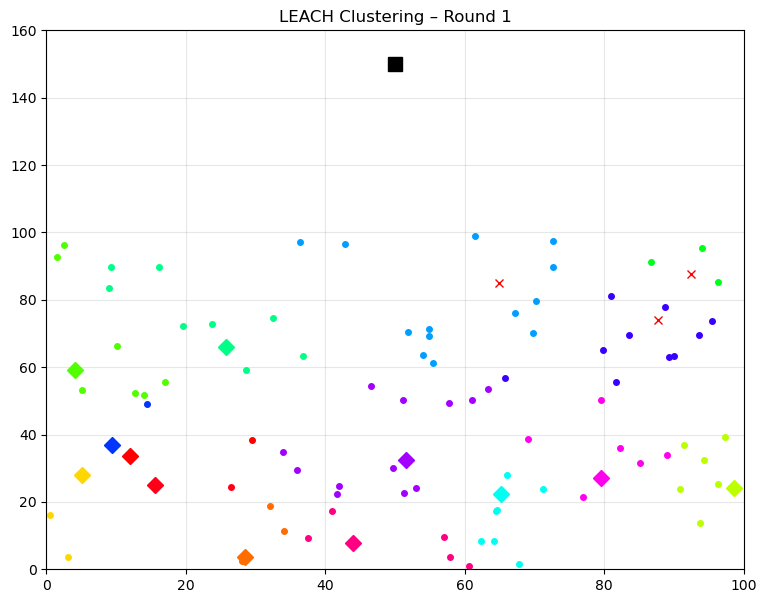

Round 100 → Alive=1, CHs=1


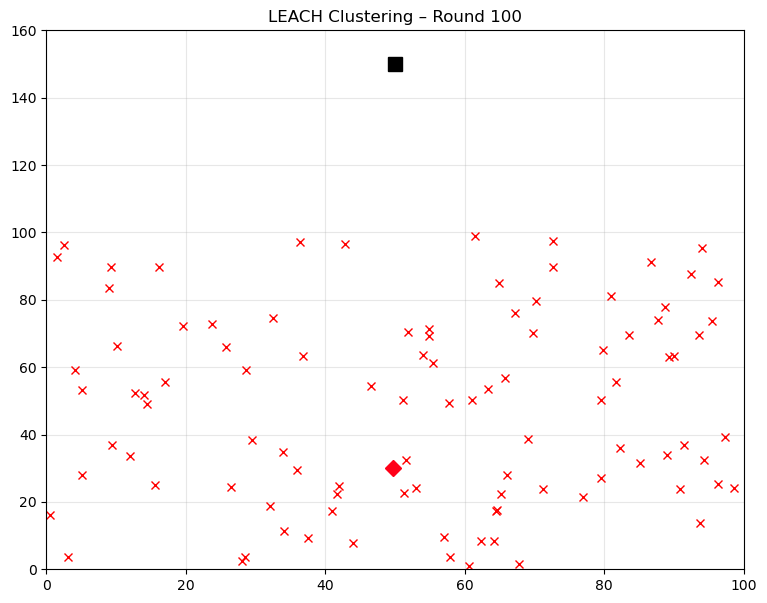

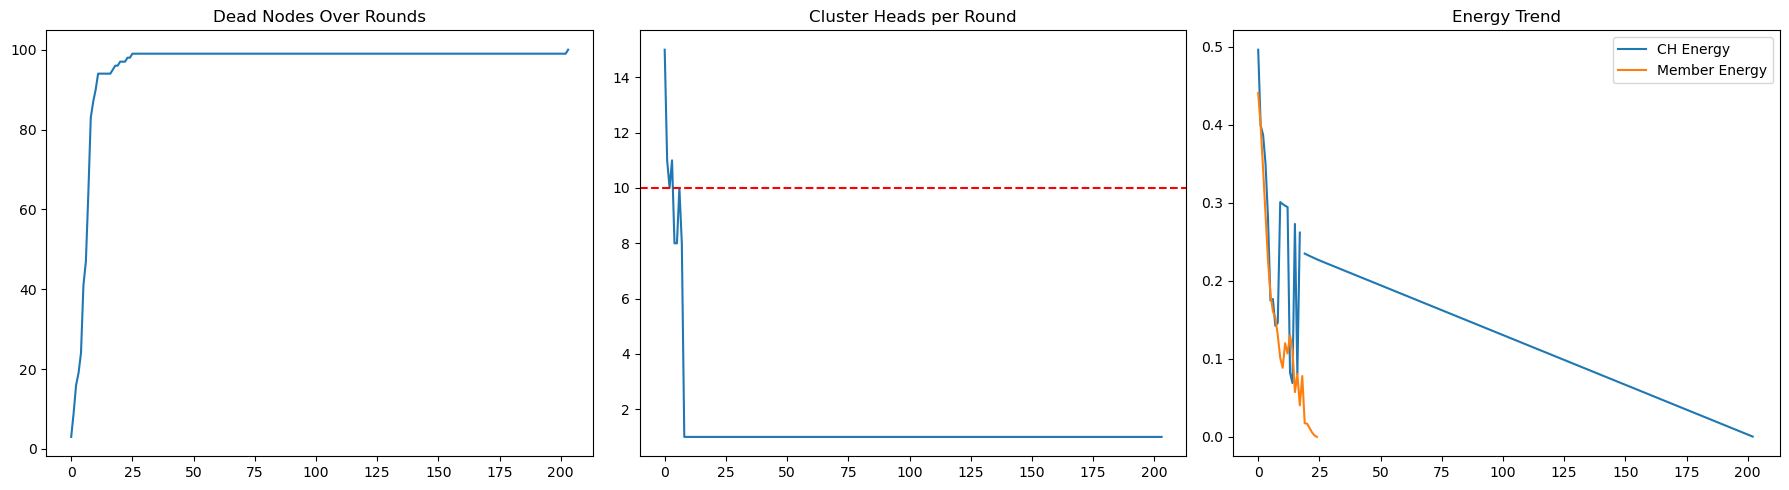


Simulation Finished
First node died at round: 0
Total rounds simulated: 204


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import random
import os

# ------------------ CREATE IMAGES FOLDER ------------------
os.makedirs("images", exist_ok=True)

# ------------------ CONSTANTS ------------------
NUM_NODES = 100
FIELD_SIZE = 100
NUM_ROUNDS = 2000

E_elec = 50e-9
E_fs   = 50e-9
E_mp   = 0.0013e-12
d0 = 87
P = 0.1
E_DATA_BITS = 4000

BS_X, BS_Y = FIELD_SIZE / 2, FIELD_SIZE + 50

np.random.seed(42)
random.seed(42)

EPOCH = int(1 / P)

# ------------------ NODE CLASS ------------------
class Node:
    def __init__(self, i, x, y, energy):
        self.id = i
        self.x = x
        self.y = y
        self.energy = energy
        self.is_dead = False
        self.is_cluster_head = False
        self.cluster_head_id = None
        self.rounds_since_ch = EPOCH

    def distance(self, x, y):
        return np.sqrt((self.x - x) ** 2 + (self.y - y) ** 2)

    def tx_energy(self, d, bits=E_DATA_BITS):
        if d <= d0:
            return E_elec * bits + E_fs * bits * d ** 2
        else:
            return E_elec * bits + E_mp * bits * d ** 4

    def consume(self, energy):
        self.energy -= energy
        if self.energy <= 0:
            self.energy = 0
            self.is_dead = True

# ------------------ INITIALIZATION ------------------
def initialize_network():
    nodes = []
    energies = np.clip(np.random.normal(0.5, 0.1, NUM_NODES), 0.1, 1.0)

    for i in range(NUM_NODES):
        x = np.random.uniform(0, FIELD_SIZE)
        y = np.random.uniform(0, FIELD_SIZE)
        nodes.append(Node(i, x, y, energies[i]))

    print(f"Initial Energy Mean = {energies.mean():.3f}")
    return nodes

# ------------------ LEACH ROUND ------------------
def run_leach_round(nodes, r):
    alive = [n for n in nodes if not n.is_dead]
    if not alive:
        return 0, [], 0, 0

    cluster_heads = []

    for n in alive:
        n.is_cluster_head = False

        if n.rounds_since_ch >= EPOCH:
            T = P / (1 - P * (r % EPOCH)) if (1 - P * (r % EPOCH)) > 0 else P
        else:
            T = 0

        if random.random() < T:
            n.is_cluster_head = True
            n.cluster_head_id = n.id
            n.rounds_since_ch = 0
            cluster_heads.append(n)
        else:
            n.rounds_since_ch += 1

    if not cluster_heads:
        best = max(alive, key=lambda n: n.energy)
        best.is_cluster_head = True
        best.cluster_head_id = best.id
        best.rounds_since_ch = 0
        cluster_heads.append(best)

    for n in alive:
        if n.is_cluster_head:
            continue

        nearest_ch = min(cluster_heads,
                         key=lambda ch: n.distance(ch.x, ch.y))
        n.cluster_head_id = nearest_ch.id

        d = n.distance(nearest_ch.x, nearest_ch.y)
        n.consume(n.tx_energy(d))

    for ch in cluster_heads:
        if ch.is_dead:
            continue

        members = [n for n in alive if n.cluster_head_id == ch.id and n.id != ch.id]
        ch.consume(E_elec * E_DATA_BITS * len(members) * 0.5)

        if not ch.is_dead:
            d_bs = ch.distance(BS_X, BS_Y)
            ch.consume(ch.tx_energy(d_bs))

    alive_nodes = [n for n in nodes if not n.is_dead]
    ch_energy = np.mean([c.energy for c in cluster_heads if not c.is_dead]) if cluster_heads else 0
    mem_energy = np.mean([n.energy for n in alive_nodes if not n.is_cluster_head]) if alive_nodes else 0

    return len(alive_nodes), cluster_heads, ch_energy, mem_energy

# ------------------ PLOT CLUSTERING ------------------
def plot_clustering(nodes, chs, r):
    plt.figure(figsize=(9, 7))
    plt.title(f"LEACH Clustering – Round {r}")
    plt.grid(True, alpha=0.3)

    cmap = plt.colormaps.get_cmap("hsv").resampled(max(1, len(chs)))
    ch_map = {ch.id: i for i, ch in enumerate(chs)}

    plt.plot(BS_X, BS_Y, 'ks', markersize=10, label="Base Station")

    for n in nodes:
        if n.is_dead:
            plt.plot(n.x, n.y, 'rx')
        elif n.is_cluster_head:
            plt.plot(n.x, n.y, 'D', color=cmap(ch_map[n.id]), markersize=8)
        else:
            idx = ch_map.get(n.cluster_head_id, 0)
            plt.plot(n.x, n.y, 'o', color=cmap(idx), markersize=4)

    plt.xlim(0, FIELD_SIZE)
    plt.ylim(0, FIELD_SIZE + 60)

    # SAVE IMAGE
    plt.savefig(f"images/clustering_round_{r}.png")

    plt.show()
    plt.close()

# ------------------ PLOT ANALYSIS ------------------
def plot_analysis(dead, ch_count, ch_e, mem_e):
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))

    ax[0].plot(dead)
    ax[0].set_title("Dead Nodes Over Rounds")

    ax[1].plot(ch_count)
    ax[1].axhline(NUM_NODES * P, linestyle='--', color='r')
    ax[1].set_title("Cluster Heads per Round")

    ax[2].plot(ch_e, label="CH Energy")
    ax[2].plot(mem_e, label="Member Energy")
    ax[2].legend()
    ax[2].set_title("Energy Trend")

    plt.tight_layout()

    # SAVE FINAL GRAPH
    plt.savefig("images/final_analysis.png")

    plt.show()
    plt.close()

# ------------------ MAIN ------------------
if __name__ == "__main__":
    nodes = initialize_network()

    dead_nodes = []
    ch_counts = []
    ch_energy = []
    mem_energy = []

    for r in range(1, NUM_ROUNDS + 1):
        alive, chs, ce, me = run_leach_round(nodes, r)

        dead_nodes.append(NUM_NODES - alive)
        ch_counts.append(len(chs))
        ch_energy.append(ce)
        mem_energy.append(me)

        if r in [1, 100, 300, 600]:
            print(f"Round {r} → Alive={alive}, CHs={len(chs)}")
            plot_clustering(nodes, chs, r)

        if alive == 0:
            break

    plot_analysis(dead_nodes, ch_counts, ch_energy, mem_energy)

    print("\nSimulation Finished")
    print("First node died at round:",
          next((i for i, x in enumerate(dead_nodes) if x > 0), "Never"))
    print("Total rounds simulated:", r)

Running LEACH...
Running SEP...


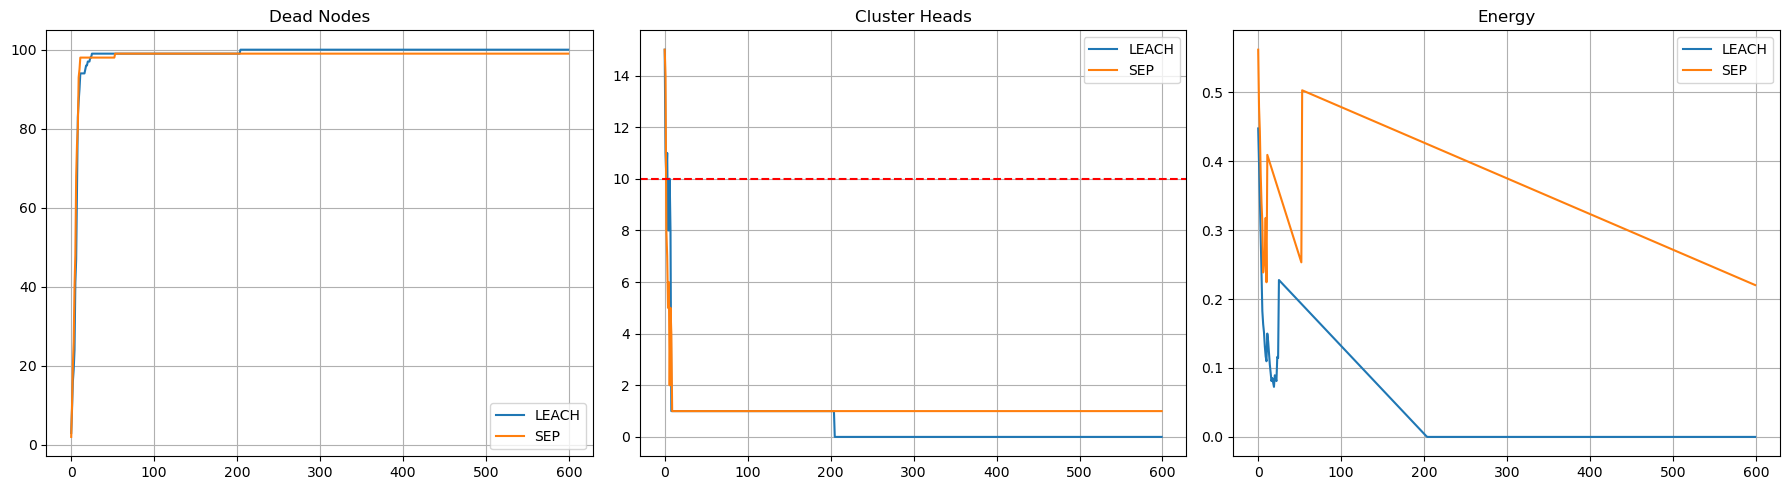


Saved in images folder:
- leach_vs_sep_analysis.png
- results.txt


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math
import os

# -----------------------------
# CREATE IMAGES FOLDER
# -----------------------------
os.makedirs("images", exist_ok=True)

# -----------------------------
# GLOBAL CONSTANTS
# -----------------------------
NUM_NODES = 100
FIELD_SIZE = 100
NUM_ROUNDS = 600

E_elec = 50e-9
E_fs   = 50e-9
E_mp   = 0.0013e-12
d0 = 87.0
E_BITS = 4000

BS_X, BS_Y = FIELD_SIZE/2, FIELD_SIZE + 50

P = 0.1
m = 0.2
alpha = 1.0

P_normal = P / (1 + alpha*m)
P_adv    = P * (1 + alpha) / (1 + alpha*m)

np.random.seed(42)
random.seed(42)

# -----------------------------
# NODE CLASS
# -----------------------------
class Node:
    def __init__(self, idx, x, y, energy, ntype='normal'):
        self.id = idx
        self.x = x
        self.y = y
        self.energy = energy
        self.type = ntype
        self.is_dead = False
        self.is_cluster_head = False
        self.cluster_head_id = None
        self.rounds_since_ch = 0

    def dist(self, x2, y2):
        return math.hypot(self.x - x2, self.y - y2)

    def consume_tx(self, d, bits=E_BITS):
        if self.is_dead:
            return
        if d <= d0:
            cost = E_elec*bits + E_fs*bits*(d**2)
        else:
            cost = E_elec*bits + E_mp*bits*(d**4)
        self.energy -= cost
        if self.energy <= 0:
            self.energy = 0
            self.is_dead = True

    def consume_rx(self, bits=E_BITS):
        if self.is_dead:
            return
        self.energy -= E_elec*bits
        if self.energy <= 0:
            self.energy = 0
            self.is_dead = True

# -----------------------------
# INITIALIZATION
# -----------------------------
def init_leach():
    energies = np.clip(np.random.normal(0.5, 0.1, NUM_NODES), 0.1, 1.0)
    nodes = []
    for i in range(NUM_NODES):
        x = np.random.uniform(0, FIELD_SIZE)
        y = np.random.uniform(0, FIELD_SIZE)
        nd = Node(i, x, y, energies[i], 'normal')
        nd.rounds_since_ch = int(1/P)
        nodes.append(nd)
    return nodes

def init_sep():
    base = np.clip(np.random.normal(0.5, 0.1, NUM_NODES), 0.1, 1.0)
    nodes = []
    adv_count = int(m * NUM_NODES)
    adv_ids = set(random.sample(range(NUM_NODES), adv_count))

    for i in range(NUM_NODES):
        x = np.random.uniform(0, FIELD_SIZE)
        y = np.random.uniform(0, FIELD_SIZE)

        if i in adv_ids:
            energy = base[i] * (1 + alpha)
            nd = Node(i, x, y, energy, 'advanced')
            nd.rounds_since_ch = int(1/P_adv)
        else:
            energy = base[i]
            nd = Node(i, x, y, energy, 'normal')
            nd.rounds_since_ch = int(1/P_normal)

        nodes.append(nd)
    return nodes

# -----------------------------
# CLUSTER HEAD SELECTION
# -----------------------------
def select_CH(nodes, r, protocol):
    CHs = []
    active = [n for n in nodes if not n.is_dead]

    for node in active:
        node.is_cluster_head = False
        p = P if protocol == 'LEACH' else (P_adv if node.type == 'advanced' else P_normal)
        epoch = int(1/p)

        if node.rounds_since_ch >= epoch:
            denom = 1 - p*(r % epoch)
            Tn = p/denom if denom > 0 else p
        else:
            Tn = 0

        if random.random() < Tn and node.energy > 0:
            node.is_cluster_head = True
            node.cluster_head_id = node.id
            node.rounds_since_ch = 0
            CHs.append(node)
        else:
            node.rounds_since_ch += 1

    if not CHs and active:
        rich = max(active, key=lambda n: n.energy)
        rich.is_cluster_head = True
        rich.cluster_head_id = rich.id
        rich.rounds_since_ch = 0
        CHs.append(rich)

    return CHs

# -----------------------------
# CLUSTERING + TRANSMISSION
# -----------------------------
def cluster_and_transmit(nodes, CHs):
    active = [n for n in nodes if not n.is_dead]
    nonCH = [n for n in active if not n.is_cluster_head]

    for nd in nonCH:
        nearest = min(CHs, key=lambda ch: nd.dist(ch.x, ch.y)) if CHs else None

        if nearest:
            nd.cluster_head_id = nearest.id
            nd.consume_tx(nd.dist(nearest.x, nearest.y))
        else:
            nd.consume_tx(nd.dist(BS_X, BS_Y))

    for ch in CHs:
        if ch.is_dead:
            continue

        members = [n for n in nodes if n.cluster_head_id == ch.id and n.id != ch.id and not n.is_dead]

        if members:
            ch.energy -= E_elec * E_BITS * len(members) * 0.5
            if ch.energy <= 0:
                ch.energy = 0
                ch.is_dead = True

        ch.consume_tx(ch.dist(BS_X, BS_Y))

# -----------------------------
# SIMULATION
# -----------------------------
def simulate(protocol):
    nodes = init_leach() if protocol == 'LEACH' else init_sep()

    dead_list = []
    ch_count_list = []
    avg_energy_list = []

    for r in range(1, NUM_ROUNDS + 1):
        CHs = select_CH(nodes, r, protocol)
        cluster_and_transmit(nodes, CHs)

        dead_list.append(len([n for n in nodes if n.is_dead]))
        ch_count_list.append(len(CHs))

        alive_energy = [n.energy for n in nodes if not n.is_dead]
        avg_energy_list.append(np.mean(alive_energy) if alive_energy else 0)

    return dead_list, ch_count_list, avg_energy_list

# -----------------------------
# FIRST NODE DEATH
# -----------------------------
def first_death_round(dead):
    for i, d in enumerate(dead):
        if d > 0:
            return i + 1
    return None

# -----------------------------
# RUN SIMULATION
# -----------------------------
print("Running LEACH...")
dead_L, ch_L, avgE_L = simulate("LEACH")

print("Running SEP...")
dead_S, ch_S, avgE_S = simulate("SEP")

# -----------------------------
# PLOT + SAVE
# -----------------------------
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.plot(dead_L, label="LEACH")
plt.plot(dead_S, label="SEP")
plt.title("Dead Nodes")
plt.legend()
plt.grid()

plt.subplot(1,3,2)
plt.plot(ch_L, label="LEACH")
plt.plot(ch_S, label="SEP")
plt.axhline(NUM_NODES * P, linestyle='--', color='r')
plt.title("Cluster Heads")
plt.legend()
plt.grid()

plt.subplot(1,3,3)
plt.plot(avgE_L, label="LEACH")
plt.plot(avgE_S, label="SEP")
plt.title("Energy")
plt.legend()
plt.grid()

plt.tight_layout()
plt.savefig("images/leach_vs_sep_analysis.png")
plt.show()
plt.close()

# -----------------------------
# SAVE RESULTS
# -----------------------------
with open("images/results.txt", "w") as f:
    f.write("LEACH vs SEP Results\n\n")
    f.write(f"LEACH First Death: {first_death_round(dead_L)}\n")
    f.write(f"SEP First Death: {first_death_round(dead_S)}\n")
    f.write(f"LEACH Total Rounds: {len(dead_L)}\n")
    f.write(f"SEP Total Rounds: {len(dead_S)}\n")

print("\nSaved in images folder:")
print("- leach_vs_sep_analysis.png")
print("- results.txt")

Running SEP–ACO...


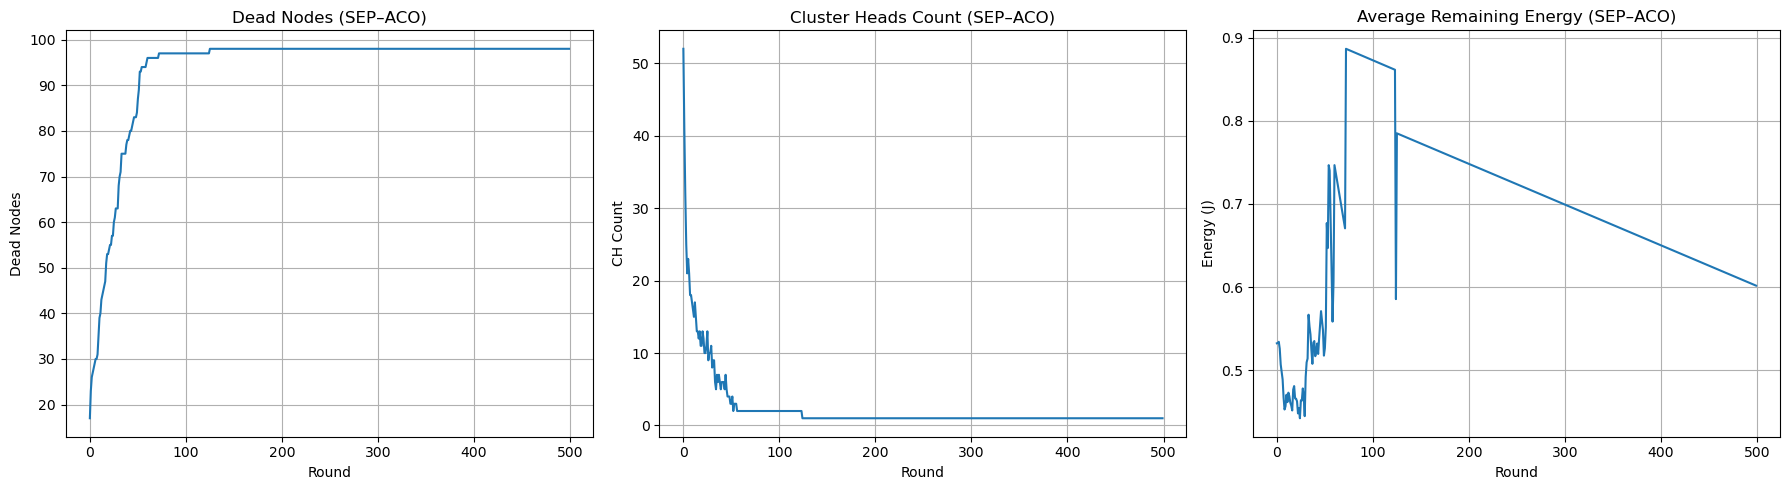

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math

# ======================================================
# 1. GLOBAL PARAMETERS
# ======================================================
NUM_NODES = 100
FIELD_SIZE = 100
NUM_ROUNDS = 500
BS_X, BS_Y = FIELD_SIZE/2, FIELD_SIZE + 50

# Energy model
E_elec = 50e-9
E_fs   = 50e-9
E_mp   = 0.0013e-12
d0 = 87
DATA_BITS = 4000

# SEP parameters
P = 0.1
m = 0.2
alpha = 1.0

# ACO parameters
NUM_ANTS = 10
ALPHA = 1.0       # pheromone importance
BETA = 2.0        # heuristic importance
RHO = 0.3         # evaporation rate
Q = 1.0           # pheromone deposit constant

np.random.seed(42)
random.seed(42)


# ======================================================
# 2. NODE CLASS
# ======================================================
class Node:
    def __init__(self, idx, x, y, energy, ntype):
        self.id = idx
        self.x = x
        self.y = y
        self.energy = energy
        self.type = ntype   # normal / advanced
        self.is_dead = False
        self.is_CH = False
        self.cluster_head_id = None

    def distance(self, x2, y2):
        return math.hypot(self.x - x2, self.y - y2)

    def consume_tx(self, d):
        if self.is_dead:
            return
        if d <= d0:
            cost = E_elec*DATA_BITS + E_fs*DATA_BITS*(d**2)
        else:
            cost = E_elec*DATA_BITS + E_mp*DATA_BITS*(d**4)
        self.energy -= cost
        if self.energy <= 0:
            self.energy = 0
            self.is_dead = True


# ======================================================
# 3. INITIALIZE SEP NETWORK
# ======================================================
def init_sep():
    nodes = []
    base_energy = np.clip(np.random.normal(0.5,0.1,NUM_NODES),0.1,1.0)
    adv_count = int(m * NUM_NODES)
    adv_ids = set(random.sample(range(NUM_NODES), adv_count))

    for i in range(NUM_NODES):
        x = np.random.uniform(0, FIELD_SIZE)
        y = np.random.uniform(0, FIELD_SIZE)
        if i in adv_ids:
            energy = base_energy[i] * (1 + alpha)
            ntype = "advanced"
        else:
            energy = base_energy[i]
            ntype = "normal"
        nodes.append(Node(i, x, y, energy, ntype))
    return nodes


# ======================================================
# 4. ACO-BASED CLUSTER HEAD SELECTION
# ======================================================
def select_CH_ACO(nodes, pheromone):
    alive_nodes = [n for n in nodes if not n.is_dead]
    num_CH = max(1, int(P * len(alive_nodes)))

    # heuristic = energy / distance_to_BS
    heuristic = {}
    for n in alive_nodes:
        d = n.distance(BS_X, BS_Y)
        heuristic[n.id] = (n.energy + 1e-6) / (d + 1e-6)

    selected_CHs = set()

    for _ in range(NUM_ANTS):
        probabilities = []
        for n in alive_nodes:
            tau = pheromone[n.id] ** ALPHA
            eta = heuristic[n.id] ** BETA
            probabilities.append(tau * eta)

        probabilities = np.array(probabilities)
        probabilities = probabilities / probabilities.sum()

        chosen = np.random.choice(len(alive_nodes), size=num_CH, replace=False, p=probabilities)
        for idx in chosen:
            selected_CHs.add(alive_nodes[idx].id)

    # reset CH flags
    for n in nodes:
        n.is_CH = False
        n.cluster_head_id = None

    CHs = []
    for n in nodes:
        if n.id in selected_CHs:
            n.is_CH = True
            CHs.append(n)

    # pheromone evaporation
    for i in pheromone:
        pheromone[i] *= (1 - RHO)

    # pheromone update
    for ch in CHs:
        pheromone[ch.id] += Q * ch.energy

    return CHs


# ======================================================
# 5. CLUSTERING + DATA TRANSMISSION
# ======================================================
def clustering_and_tx(nodes, CHs):
    alive = [n for n in nodes if not n.is_dead]
    members = [n for n in alive if not n.is_CH]

    for n in members:
        nearest = min(CHs, key=lambda ch: n.distance(ch.x, ch.y))
        n.cluster_head_id = nearest.id
        n.consume_tx(n.distance(nearest.x, nearest.y))

    for ch in CHs:
        if ch.is_dead:
            continue
        ch.consume_tx(ch.distance(BS_X, BS_Y))


# ======================================================
# 6. SIMULATION LOOP
# ======================================================
def simulate_SEP_ACO():
    nodes = init_sep()
    pheromone = {i: 1.0 for i in range(NUM_NODES)}

    dead_nodes = []
    ch_count = []
    avg_energy = []

    for r in range(NUM_ROUNDS):
        CHs = select_CH_ACO(nodes, pheromone)
        clustering_and_tx(nodes, CHs)

        dead_nodes.append(len([n for n in nodes if n.is_dead]))
        ch_count.append(len(CHs))

        alive_energy = [n.energy for n in nodes if not n.is_dead]
        avg_energy.append(np.mean(alive_energy) if alive_energy else 0)

        if len(alive_energy) == 0:
            break

    return np.array(dead_nodes), np.array(ch_count), np.array(avg_energy)


# ======================================================
# 7. RUN SIMULATION
# ======================================================
print("Running SEP–ACO...")
dead, chs, energy = simulate_SEP_ACO()


# ======================================================
# 8. PLOTS
# ======================================================
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.plot(dead)
plt.title("Dead Nodes (SEP–ACO)")
plt.xlabel("Round")
plt.ylabel("Dead Nodes")
plt.grid(True)

plt.subplot(1,3,2)
plt.plot(chs)
plt.title("Cluster Heads Count (SEP–ACO)")
plt.xlabel("Round")
plt.ylabel("CH Count")
plt.grid(True)

plt.subplot(1,3,3)
plt.plot(energy)
plt.title("Average Remaining Energy (SEP–ACO)")
plt.xlabel("Round")
plt.ylabel("Energy (J)")
plt.grid(True)

plt.tight_layout()
plt.show()


Running LEACH–ACO...


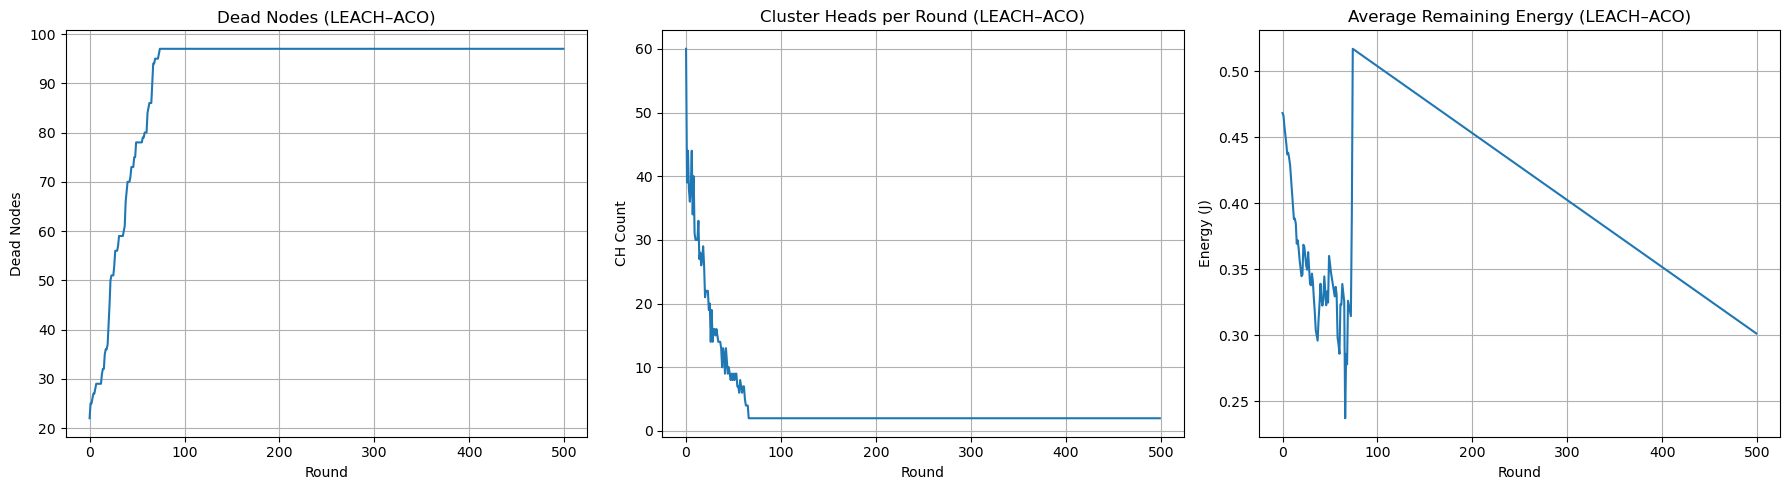

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math

# ======================================================
# 1. GLOBAL PARAMETERS
# ======================================================
NUM_NODES = 100
FIELD_SIZE = 100
NUM_ROUNDS = 500

BS_X, BS_Y = FIELD_SIZE / 2, FIELD_SIZE + 50

# Energy model
E_elec = 50e-9
E_fs   = 50e-9
E_mp   = 0.0013e-12
d0 = 87
DATA_BITS = 4000

# LEACH parameter
P = 0.1   # desired CH percentage

# ACO parameters
NUM_ANTS = 10
ALPHA = 1.0
BETA = 2.0
RHO = 0.3
Q = 1.0

np.random.seed(42)
random.seed(42)


# ======================================================
# 2. NODE CLASS
# ======================================================
class Node:
    def __init__(self, idx, x, y, energy):
        self.id = idx
        self.x = x
        self.y = y
        self.energy = energy
        self.is_dead = False
        self.is_CH = False
        self.cluster_head_id = None

    def distance(self, x2, y2):
        return math.hypot(self.x - x2, self.y - y2)

    def consume_tx(self, d):
        if self.is_dead:
            return
        if d <= d0:
            cost = E_elec * DATA_BITS + E_fs * DATA_BITS * (d ** 2)
        else:
            cost = E_elec * DATA_BITS + E_mp * DATA_BITS * (d ** 4)
        self.energy -= cost
        if self.energy <= 0:
            self.energy = 0
            self.is_dead = True


# ======================================================
# 3. INITIALIZE LEACH NETWORK
# ======================================================
def init_leach():
    nodes = []
    energies = np.clip(np.random.normal(0.5, 0.1, NUM_NODES), 0.1, 1.0)

    for i in range(NUM_NODES):
        x = np.random.uniform(0, FIELD_SIZE)
        y = np.random.uniform(0, FIELD_SIZE)
        nodes.append(Node(i, x, y, energies[i]))

    return nodes


# ======================================================
# 4. ACO-BASED CLUSTER HEAD SELECTION
# ======================================================
def select_CH_ACO(nodes, pheromone):
    alive = [n for n in nodes if not n.is_dead]
    if not alive:
        return []

    num_CH = max(1, int(P * len(alive)))

    # heuristic = remaining energy / distance to BS
    heuristic = {}
    for n in alive:
        d = n.distance(BS_X, BS_Y)
        heuristic[n.id] = (n.energy + 1e-6) / (d + 1e-6)

    selected_CH_ids = set()

    for _ in range(NUM_ANTS):
        probs = []
        for n in alive:
            tau = pheromone[n.id] ** ALPHA
            eta = heuristic[n.id] ** BETA
            probs.append(tau * eta)

        probs = np.array(probs)
        probs = probs / probs.sum()

        chosen = np.random.choice(len(alive), num_CH, replace=False, p=probs)
        for idx in chosen:
            selected_CH_ids.add(alive[idx].id)

    # reset CH flags
    for n in nodes:
        n.is_CH = False
        n.cluster_head_id = None

    CHs = []
    for n in nodes:
        if n.id in selected_CH_ids:
            n.is_CH = True
            CHs.append(n)

    # pheromone evaporation
    for k in pheromone:
        pheromone[k] *= (1 - RHO)

    # pheromone reinforcement
    for ch in CHs:
        pheromone[ch.id] += Q * ch.energy

    return CHs


# ======================================================
# 5. CLUSTERING + TRANSMISSION
# ======================================================
def clustering_and_tx(nodes, CHs):
    alive = [n for n in nodes if not n.is_dead]
    members = [n for n in alive if not n.is_CH]

    # member → CH
    for n in members:
        nearest = min(CHs, key=lambda ch: n.distance(ch.x, ch.y))
        n.cluster_head_id = nearest.id
        n.consume_tx(n.distance(nearest.x, nearest.y))

    # CH → BS
    for ch in CHs:
        if not ch.is_dead:
            ch.consume_tx(ch.distance(BS_X, BS_Y))


# ======================================================
# 6. SIMULATION LOOP
# ======================================================
def simulate_LEACH_ACO():
    nodes = init_leach()
    pheromone = {i: 1.0 for i in range(NUM_NODES)}

    dead_nodes = []
    ch_count = []
    avg_energy = []

    for r in range(NUM_ROUNDS):
        CHs = select_CH_ACO(nodes, pheromone)
        clustering_and_tx(nodes, CHs)

        dead_nodes.append(len([n for n in nodes if n.is_dead]))
        ch_count.append(len(CHs))

        alive_energy = [n.energy for n in nodes if not n.is_dead]
        avg_energy.append(np.mean(alive_energy) if alive_energy else 0)

        if not alive_energy:
            break

    return np.array(dead_nodes), np.array(ch_count), np.array(avg_energy)


# ======================================================
# 7. RUN SIMULATION
# ======================================================
print("Running LEACH–ACO...")
dead, chs, energy = simulate_LEACH_ACO()


# ======================================================
# 8. RESULTS PLOTS (FIXED)
# ======================================================
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(dead)
plt.title("Dead Nodes (LEACH–ACO)")
plt.xlabel("Round")
plt.ylabel("Dead Nodes")
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(chs)
plt.title("Cluster Heads per Round (LEACH–ACO)")
plt.xlabel("Round")
plt.ylabel("CH Count")
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(energy)
plt.title("Average Remaining Energy (LEACH–ACO)")
plt.xlabel("Round")
plt.ylabel("Energy (J)")
plt.grid(True)

plt.tight_layout()
plt.show()


Running LEACH–BAT...


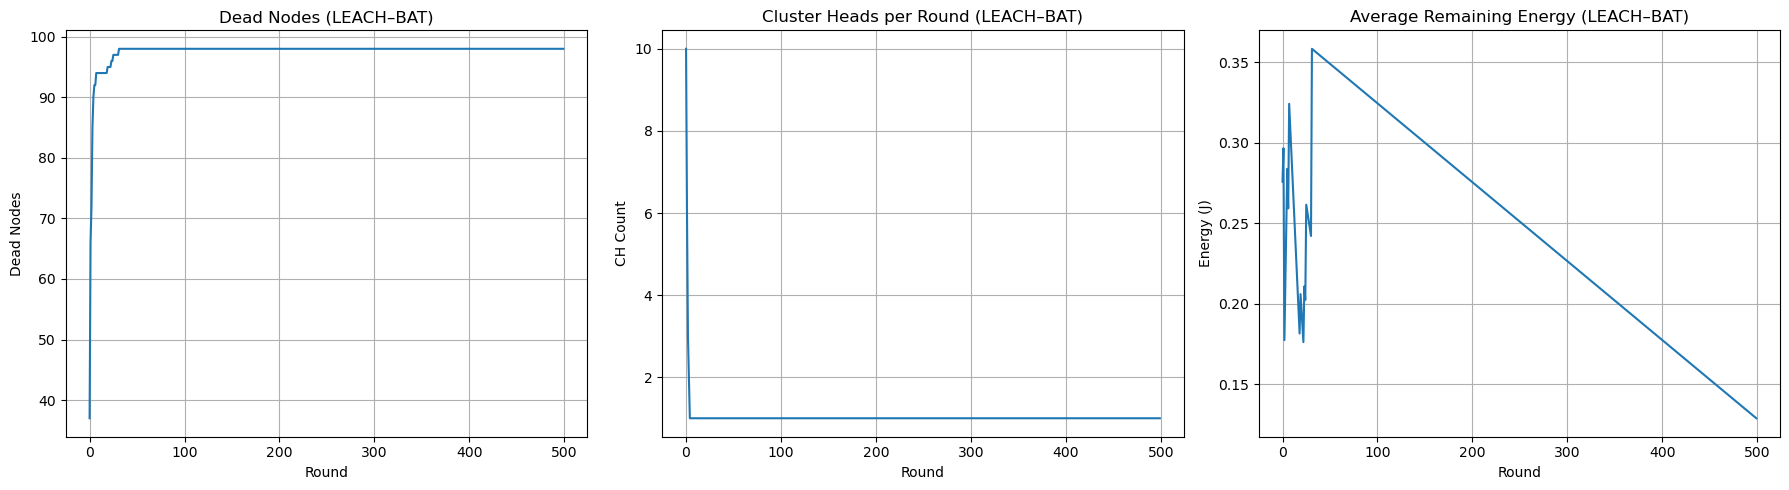

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math

# ======================================================
# 1. GLOBAL PARAMETERS
# ======================================================
NUM_NODES = 100
FIELD_SIZE = 100
NUM_ROUNDS = 500

BS_X, BS_Y = FIELD_SIZE/2, FIELD_SIZE + 50

# Energy model
E_elec = 50e-9
E_fs   = 50e-9
E_mp   = 0.0013e-12
d0 = 87
DATA_BITS = 4000

# LEACH parameters
P = 0.1   # desired CH percentage

# BAT algorithm parameters
NUM_BATS = 10
A = 0.5          # loudness
R = 0.5          # pulse rate
Qmin = 0.0       # frequency min
Qmax = 2.0       # frequency max

np.random.seed(42)
random.seed(42)


# ======================================================
# 2. NODE CLASS
# ======================================================
class Node:
    def __init__(self, idx, x, y, energy):
        self.id = idx
        self.x = x
        self.y = y
        self.energy = energy
        self.is_dead = False
        self.is_CH = False
        self.cluster_head_id = None

    def distance(self, x2, y2):
        return math.hypot(self.x - x2, self.y - y2)

    def consume_tx(self, d):
        if self.is_dead:
            return
        if d <= d0:
            cost = E_elec*DATA_BITS + E_fs*DATA_BITS*(d**2)
        else:
            cost = E_elec*DATA_BITS + E_mp*DATA_BITS*(d**4)
        self.energy -= cost
        if self.energy <= 0:
            self.energy = 0
            self.is_dead = True


# ======================================================
# 3. INITIALIZE LEACH NETWORK
# ======================================================
def init_leach():
    nodes = []
    energies = np.clip(np.random.normal(0.5, 0.1, NUM_NODES), 0.1, 1.0)
    for i in range(NUM_NODES):
        x = np.random.uniform(0, FIELD_SIZE)
        y = np.random.uniform(0, FIELD_SIZE)
        nodes.append(Node(i, x, y, energies[i]))
    return nodes


# ======================================================
# 4. FITNESS FUNCTION (BAT)
# ======================================================
def fitness(node):
    """
    Higher fitness is better:
    - High remaining energy
    - Short distance to BS
    """
    d = node.distance(BS_X, BS_Y)
    return (node.energy + 1e-6) / (d + 1e-6)


# ======================================================
# 5. BAT-BASED CLUSTER HEAD SELECTION
# ======================================================
def select_CH_BAT(nodes):
    alive = [n for n in nodes if not n.is_dead]
    if not alive:
        return []

    num_CH = max(1, int(P * len(alive)))

    # Initialize bats randomly
    bats = random.sample(alive, min(NUM_BATS, len(alive)))
    best = max(bats, key=fitness)

    for _ in range(NUM_BATS):
        for bat in bats:
            Q = Qmin + (Qmax - Qmin) * random.random()

            # Local search around best solution
            if random.random() > R:
                candidate = best
            else:
                candidate = random.choice(alive)

            # Accept solution based on loudness
            if fitness(candidate) > fitness(bat) and random.random() < A:
                bat = candidate

            # Update global best
            if fitness(bat) > fitness(best):
                best = bat

    # Select top num_CH nodes based on fitness
    sorted_nodes = sorted(alive, key=fitness, reverse=True)
    CHs = sorted_nodes[:num_CH]

    # Reset flags
    for n in nodes:
        n.is_CH = False
        n.cluster_head_id = None

    for ch in CHs:
        ch.is_CH = True

    return CHs


# ======================================================
# 6. CLUSTERING + DATA TRANSMISSION
# ======================================================
def clustering_and_tx(nodes, CHs):
    alive = [n for n in nodes if not n.is_dead]
    members = [n for n in alive if not n.is_CH]

    # Member → CH
    for n in members:
        nearest = min(CHs, key=lambda ch: n.distance(ch.x, ch.y))
        n.cluster_head_id = nearest.id
        n.consume_tx(n.distance(nearest.x, nearest.y))

    # CH → BS
    for ch in CHs:
        if not ch.is_dead:
            ch.consume_tx(ch.distance(BS_X, BS_Y))


# ======================================================
# 7. SIMULATION LOOP
# ======================================================
def simulate_LEACH_BAT():
    nodes = init_leach()

    dead_nodes = []
    ch_count = []
    avg_energy = []

    for r in range(NUM_ROUNDS):
        CHs = select_CH_BAT(nodes)
        clustering_and_tx(nodes, CHs)

        dead_nodes.append(len([n for n in nodes if n.is_dead]))
        ch_count.append(len(CHs))

        alive_energy = [n.energy for n in nodes if not n.is_dead]
        avg_energy.append(np.mean(alive_energy) if alive_energy else 0)

        if not alive_energy:
            break

    return np.array(dead_nodes), np.array(ch_count), np.array(avg_energy)


# ======================================================
# 8. RUN SIMULATION
# ======================================================
print("Running LEACH–BAT...")
dead, chs, energy = simulate_LEACH_BAT()


# ======================================================
# 9. RESULTS PLOTS
# ======================================================
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.plot(dead)
plt.title("Dead Nodes (LEACH–BAT)")
plt.xlabel("Round")
plt.ylabel("Dead Nodes")
plt.grid(True)

plt.subplot(1,3,2)
plt.plot(chs)
plt.title("Cluster Heads per Round (LEACH–BAT)")
plt.xlabel("Round")
plt.ylabel("CH Count")
plt.grid(True)

plt.subplot(1,3,3)
plt.plot(energy)
plt.title("Average Remaining Energy (LEACH–BAT)")
plt.xlabel("Round")
plt.ylabel("Energy (J)")
plt.grid(True)

plt.tight_layout()
plt.show()


Running SEP–BAT...


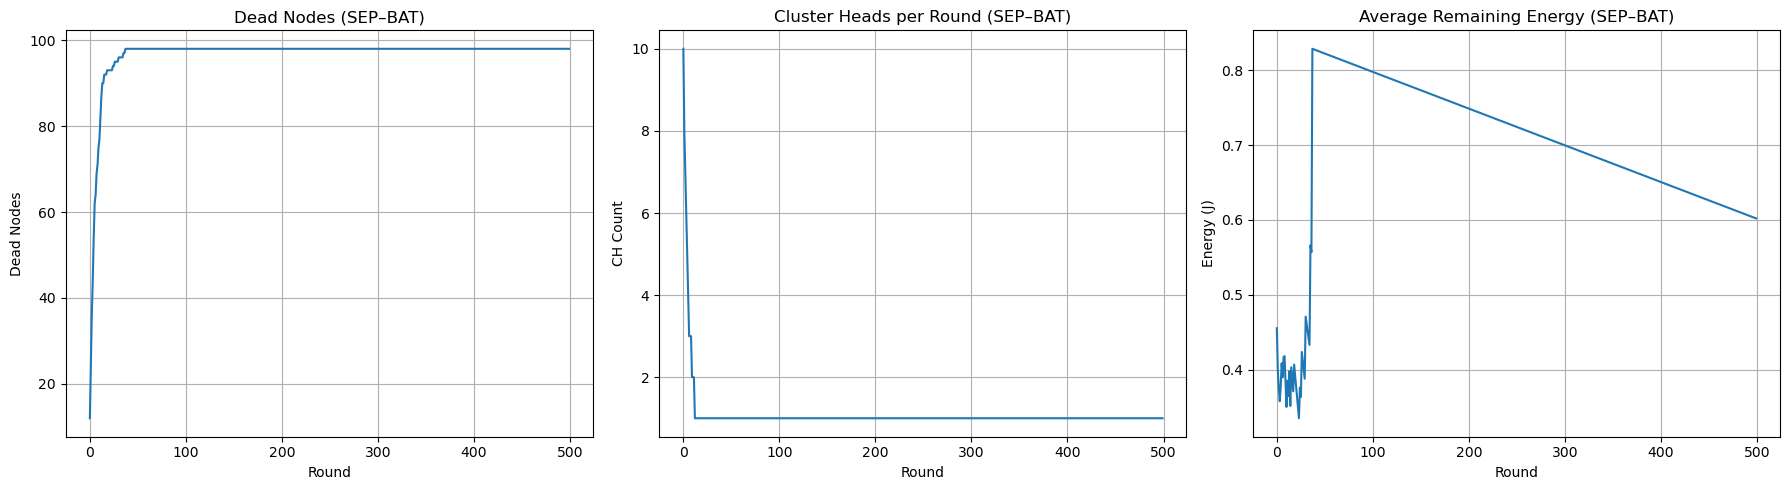

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math

# ======================================================
# 1. GLOBAL PARAMETERS
# ======================================================
NUM_NODES = 100
FIELD_SIZE = 100
NUM_ROUNDS = 500

BS_X, BS_Y = FIELD_SIZE/2, FIELD_SIZE + 50

# Energy model
E_elec = 50e-9
E_fs   = 50e-9
E_mp   = 0.0013e-12
d0 = 87
DATA_BITS = 4000

# SEP parameters
P = 0.1
m = 0.2
alpha = 1.0

# BAT parameters
NUM_BATS = 10
A = 0.5          # loudness
R = 0.5          # pulse rate
Qmin = 0.0
Qmax = 2.0

np.random.seed(42)
random.seed(42)


# ======================================================
# 2. NODE CLASS
# ======================================================
class Node:
    def __init__(self, idx, x, y, energy, ntype):
        self.id = idx
        self.x = x
        self.y = y
        self.energy = energy
        self.type = ntype  # normal / advanced
        self.is_dead = False
        self.is_CH = False
        self.cluster_head_id = None

    def distance(self, x2, y2):
        return math.hypot(self.x - x2, self.y - y2)

    def consume_tx(self, d):
        if self.is_dead:
            return
        if d <= d0:
            cost = E_elec*DATA_BITS + E_fs*DATA_BITS*(d**2)
        else:
            cost = E_elec*DATA_BITS + E_mp*DATA_BITS*(d**4)
        self.energy -= cost
        if self.energy <= 0:
            self.energy = 0
            self.is_dead = True


# ======================================================
# 3. INITIALIZE SEP NETWORK
# ======================================================
def init_sep():
    nodes = []
    base_energy = np.clip(np.random.normal(0.5, 0.1, NUM_NODES), 0.1, 1.0)

    adv_count = int(m * NUM_NODES)
    adv_ids = set(random.sample(range(NUM_NODES), adv_count))

    for i in range(NUM_NODES):
        x = np.random.uniform(0, FIELD_SIZE)
        y = np.random.uniform(0, FIELD_SIZE)

        if i in adv_ids:
            energy = base_energy[i] * (1 + alpha)
            ntype = "advanced"
        else:
            energy = base_energy[i]
            ntype = "normal"

        nodes.append(Node(i, x, y, energy, ntype))

    return nodes


# ======================================================
# 4. FITNESS FUNCTION (BAT)
# ======================================================
def fitness(node):
    """
    Higher is better:
    - High remaining energy
    - Low distance to BS
    """
    d = node.distance(BS_X, BS_Y)
    return (node.energy + 1e-6) / (d + 1e-6)


# ======================================================
# 5. BAT-BASED CLUSTER HEAD SELECTION
# ======================================================
def select_CH_BAT(nodes):
    alive = [n for n in nodes if not n.is_dead]
    if not alive:
        return []

    num_CH = max(1, int(P * len(alive)))

    # Initialize bats
    bats = random.sample(alive, min(NUM_BATS, len(alive)))
    best = max(bats, key=fitness)

    for _ in range(NUM_BATS):
        for bat in bats:
            Q = Qmin + (Qmax - Qmin) * random.random()

            if random.random() > R:
                candidate = best
            else:
                candidate = random.choice(alive)

            if fitness(candidate) > fitness(bat) and random.random() < A:
                bat = candidate

            if fitness(bat) > fitness(best):
                best = bat

    # Choose best CHs based on fitness
    sorted_nodes = sorted(alive, key=fitness, reverse=True)
    CHs = sorted_nodes[:num_CH]

    # Reset CH flags
    for n in nodes:
        n.is_CH = False
        n.cluster_head_id = None

    for ch in CHs:
        ch.is_CH = True

    return CHs


# ======================================================
# 6. CLUSTERING + DATA TRANSMISSION
# ======================================================
def clustering_and_tx(nodes, CHs):
    alive = [n for n in nodes if not n.is_dead]
    members = [n for n in alive if not n.is_CH]

    # Member → CH
    for n in members:
        nearest = min(CHs, key=lambda ch: n.distance(ch.x, ch.y))
        n.cluster_head_id = nearest.id
        n.consume_tx(n.distance(nearest.x, nearest.y))

    # CH → BS
    for ch in CHs:
        if not ch.is_dead:
            ch.consume_tx(ch.distance(BS_X, BS_Y))


# ======================================================
# 7. SIMULATION LOOP
# ======================================================
def simulate_SEP_BAT():
    nodes = init_sep()

    dead_nodes = []
    ch_count = []
    avg_energy = []

    for r in range(NUM_ROUNDS):
        CHs = select_CH_BAT(nodes)
        clustering_and_tx(nodes, CHs)

        dead_nodes.append(len([n for n in nodes if n.is_dead]))
        ch_count.append(len(CHs))

        alive_energy = [n.energy for n in nodes if not n.is_dead]
        avg_energy.append(np.mean(alive_energy) if alive_energy else 0)

        if not alive_energy:
            break

    return np.array(dead_nodes), np.array(ch_count), np.array(avg_energy)


# ======================================================
# 8. RUN SIMULATION
# ======================================================
print("Running SEP–BAT...")
dead, chs, energy = simulate_SEP_BAT()


# ======================================================
# 9. RESULTS PLOTS
# ======================================================
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.plot(dead)
plt.title("Dead Nodes (SEP–BAT)")
plt.xlabel("Round")
plt.ylabel("Dead Nodes")
plt.grid(True)

plt.subplot(1,3,2)
plt.plot(chs)
plt.title("Cluster Heads per Round (SEP–BAT)")
plt.xlabel("Round")
plt.ylabel("CH Count")
plt.grid(True)

plt.subplot(1,3,3)
plt.plot(energy)
plt.title("Average Remaining Energy (SEP–BAT)")
plt.xlabel("Round")
plt.ylabel("Energy (J)")
plt.grid(True)

plt.tight_layout()
plt.show()


Running LEACH-ACO...
Running LEACH-BAT...
Running SEP-ACO...
Running SEP-BAT...


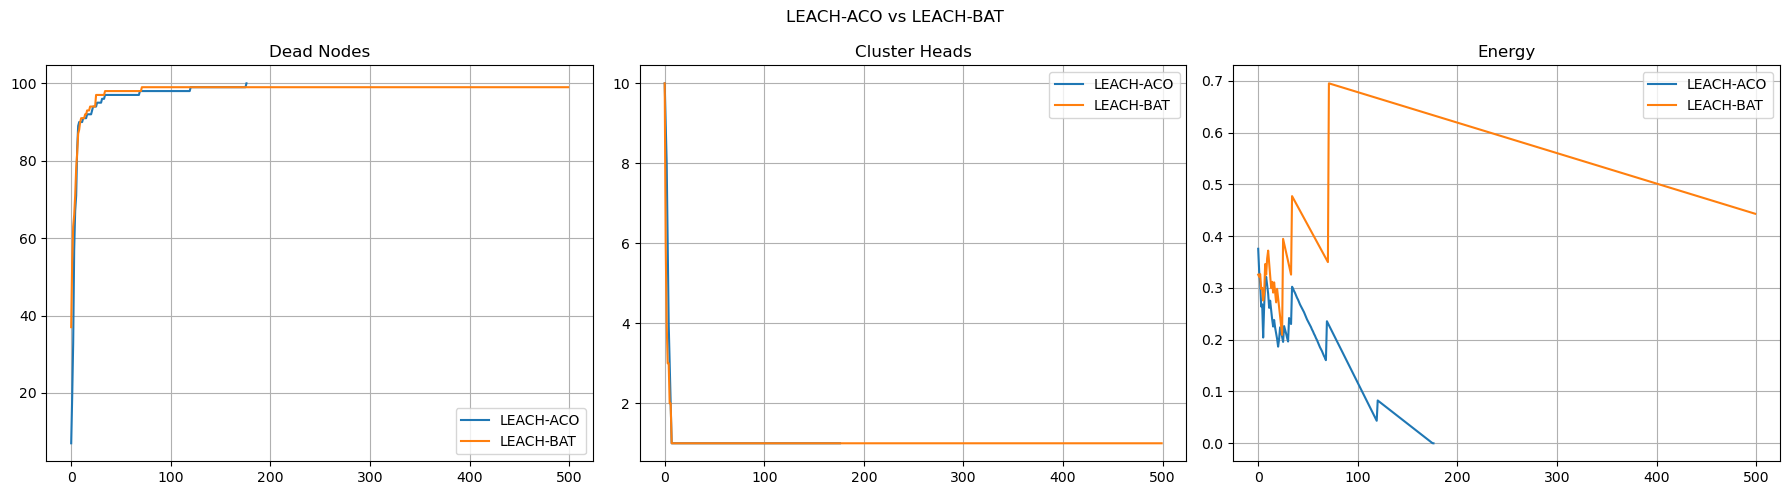

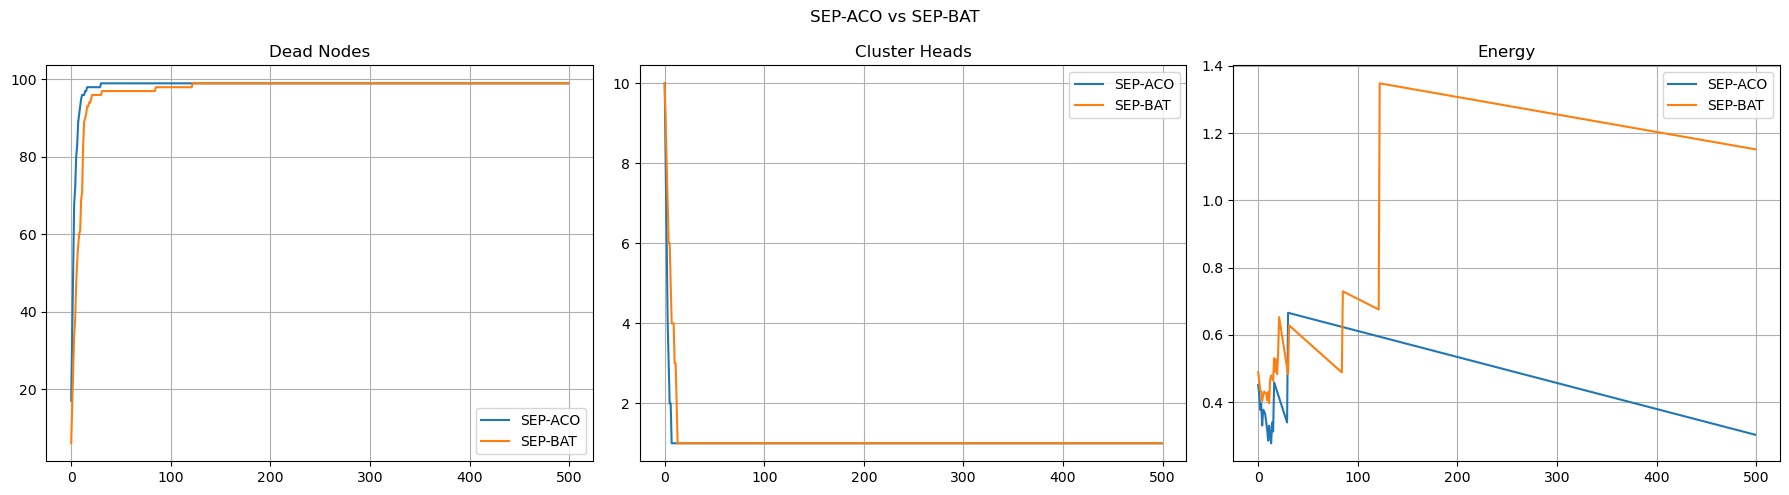


Saved in images folder:
- leach_aco_vs_bat.png
- sep_aco_vs_bat.png
- aco_bat_results.txt


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math
import os

# =============================
# CREATE IMAGES FOLDER
# =============================
os.makedirs("images", exist_ok=True)

# ======================================================
# GLOBAL PARAMETERS
# ======================================================
NUM_NODES = 100
FIELD_SIZE = 100
NUM_ROUNDS = 500

BS_X, BS_Y = FIELD_SIZE/2, FIELD_SIZE + 50

E_elec = 50e-9
E_fs   = 50e-9
E_mp   = 0.0013e-12
d0 = 87
DATA_BITS = 4000

P = 0.1
m = 0.2
alpha = 1.0

np.random.seed(42)
random.seed(42)

# ACO
NUM_ANTS = 10
ALPHA = 1.0
BETA = 2.0

# BAT
NUM_BATS = 10

# ======================================================
# NODE CLASS
# ======================================================
class Node:
    def __init__(self, idx, x, y, energy, ntype="normal"):
        self.id = idx
        self.x = x
        self.y = y
        self.energy = energy
        self.type = ntype
        self.is_dead = False
        self.is_CH = False

    def dist(self, x2, y2):
        return math.hypot(self.x - x2, self.y - y2)

    def consume_tx(self, d):
        if self.is_dead:
            return
        if d <= d0:
            cost = E_elec*DATA_BITS + E_fs*DATA_BITS*(d**2)
        else:
            cost = E_elec*DATA_BITS + E_mp*DATA_BITS*(d**4)
        self.energy -= cost
        if self.energy <= 0:
            self.energy = 0
            self.is_dead = True

# ======================================================
# INITIALIZATION
# ======================================================
def init_leach():
    energies = np.clip(np.random.normal(0.5,0.1,NUM_NODES),0.1,1.0)
    return [Node(i,np.random.uniform(0,FIELD_SIZE),
                 np.random.uniform(0,FIELD_SIZE),
                 energies[i]) for i in range(NUM_NODES)]

def init_sep():
    base = np.clip(np.random.normal(0.5,0.1,NUM_NODES),0.1,1.0)
    adv_ids = set(random.sample(range(NUM_NODES), int(m*NUM_NODES)))
    nodes=[]
    for i in range(NUM_NODES):
        energy = base[i]*(1+alpha) if i in adv_ids else base[i]
        nodes.append(Node(i,np.random.uniform(0,FIELD_SIZE),
                          np.random.uniform(0,FIELD_SIZE),
                          energy))
    return nodes

# ======================================================
# FITNESS
# ======================================================
def fitness(n):
    return (n.energy+1e-6)/(n.dist(BS_X,BS_Y)+1e-6)

# ======================================================
# ACO
# ======================================================
def select_CH_ACO(nodes):
    alive=[n for n in nodes if not n.is_dead]
    num_CH=max(1,int(P*len(alive)))
    scores=np.array([(fitness(n)**BETA) for n in alive])
    probs=scores/np.sum(scores)
    idx=np.random.choice(len(alive),num_CH,False,p=probs)
    return [alive[i] for i in idx]

# ======================================================
# BAT
# ======================================================
def select_CH_BAT(nodes):
    alive=[n for n in nodes if not n.is_dead]
    num_CH=max(1,int(P*len(alive)))
    return sorted(alive,key=fitness,reverse=True)[:num_CH]

# ======================================================
# COMMUNICATION
# ======================================================
def communicate(nodes,CHs):
    for n in nodes:
        n.is_CH = n in CHs

    members=[n for n in nodes if not n.is_dead and not n.is_CH]

    for n in members:
        ch=min(CHs,key=lambda c:n.dist(c.x,c.y))
        n.consume_tx(n.dist(ch.x,ch.y))

    for ch in CHs:
        ch.consume_tx(ch.dist(BS_X,BS_Y))

# ======================================================
# SIMULATION
# ======================================================
def simulate(init_fn,select_fn):
    nodes=init_fn()
    dead,chs,energy=[],[],[]

    for _ in range(NUM_ROUNDS):
        CHs=select_fn(nodes)
        communicate(nodes,CHs)

        dead.append(len([n for n in nodes if n.is_dead]))
        chs.append(len(CHs))
        alive=[n.energy for n in nodes if not n.is_dead]
        energy.append(np.mean(alive) if alive else 0)

        if not alive:
            break

    return dead,chs,energy

# ======================================================
# RUN ALL
# ======================================================
print("Running LEACH-ACO...")
d_LACO,c_LACO,e_LACO=simulate(init_leach,select_CH_ACO)

print("Running LEACH-BAT...")
d_LBAT,c_LBAT,e_LBAT=simulate(init_leach,select_CH_BAT)

print("Running SEP-ACO...")
d_SACO,c_SACO,e_SACO=simulate(init_sep,select_CH_ACO)

print("Running SEP-BAT...")
d_SBAT,c_SBAT,e_SBAT=simulate(init_sep,select_CH_BAT)

# ======================================================
# PLOT + SAVE FUNCTION
# ======================================================
def plot_compare(d1,d2,c1,c2,e1,e2,l1,l2,title,filename):
    plt.figure(figsize=(18,5))

    plt.subplot(1,3,1)
    plt.plot(d1,label=l1)
    plt.plot(d2,label=l2)
    plt.title("Dead Nodes")
    plt.legend(); plt.grid()

    plt.subplot(1,3,2)
    plt.plot(c1,label=l1)
    plt.plot(c2,label=l2)
    plt.title("Cluster Heads")
    plt.legend(); plt.grid()

    plt.subplot(1,3,3)
    plt.plot(e1,label=l1)
    plt.plot(e2,label=l2)
    plt.title("Energy")
    plt.legend(); plt.grid()

    plt.suptitle(title)
    plt.tight_layout()

    # SAVE GRAPH
    plt.savefig(f"images/{filename}.png")

    plt.show()
    plt.close()

# ======================================================
# GENERATE PLOTS
# ======================================================
plot_compare(d_LACO,d_LBAT,c_LACO,c_LBAT,e_LACO,e_LBAT,
             "LEACH-ACO","LEACH-BAT",
             "LEACH-ACO vs LEACH-BAT",
             "leach_aco_vs_bat")

plot_compare(d_SACO,d_SBAT,c_SACO,c_SBAT,e_SACO,e_SBAT,
             "SEP-ACO","SEP-BAT",
             "SEP-ACO vs SEP-BAT",
             "sep_aco_vs_bat")

# ======================================================
# SAVE RESULTS
# ======================================================
with open("images/aco_bat_results.txt","w") as f:
    f.write("ACO vs BAT Results\n\n")

    f.write("LEACH-ACO vs LEACH-BAT\n")
    f.write(f"ACO Final Dead: {d_LACO[-1]}\n")
    f.write(f"BAT Final Dead: {d_LBAT[-1]}\n\n")

    f.write("SEP-ACO vs SEP-BAT\n")
    f.write(f"ACO Final Dead: {d_SACO[-1]}\n")
    f.write(f"BAT Final Dead: {d_SBAT[-1]}\n")

print("\nSaved in images folder:")
print("- leach_aco_vs_bat.png")
print("- sep_aco_vs_bat.png")
print("- aco_bat_results.txt")